# Amazon Sales Analysis Project

## Project Task

### step 1: importing our libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as mno
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

### step 2: reading & loading our data

In [12]:
df = pd.read_csv(r"C:\Users\Moses Oghene\Downloads\amazon_sales_dataset.csv")
print('Successful')

Successful


### Loading the first few rows of our Adidas Sales Data

In [13]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


# Loading the last few rows of our Adidas Sales Data

In [14]:
df.tail()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


### Checking for dataset shape

In [15]:
df.shape

(50000, 13)

### Checking for dataset columns

In [17]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

### Understanding data types
#### Data type & Basic infos

In [18]:
df.dtypes

order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
dtype: object

In [19]:
df.info

<bound method DataFrame.info of        order_id  order_date  product_id product_category   price  \
0             1  2022-04-13        2637            Books  128.75   
1             2  2023-03-12        2300          Fashion  302.60   
2             3  2022-09-28        3670           Sports  495.80   
3             4  2022-04-17        2522            Books  371.95   
4             5  2022-03-13        1717           Beauty  201.68   
...         ...         ...         ...              ...     ...   
49995     49996  2022-09-03        1433           Beauty   26.99   
49996     49997  2022-07-03        1428           Beauty  294.23   
49997     49998  2023-02-17        4651      Electronics  352.11   
49998     49999  2022-09-30        4371           Beauty  307.54   
49999     50000  2023-06-29        2944   Home & Kitchen  253.44   

       discount_percent  quantity_sold customer_region payment_method  rating  \
0                    10              4   North America            UPI 

## Data Cleaning

### Checking for missing values and Handling of missing values

In [20]:
df.isna().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [21]:
df.isna().any()

order_id            False
order_date          False
product_id          False
product_category    False
price               False
discount_percent    False
quantity_sold       False
customer_region     False
payment_method      False
rating              False
review_count        False
discounted_price    False
total_revenue       False
dtype: bool

### Checking for duplicates & removal if any

In [22]:
df.duplicated().any()

np.False_

### Converting date column to proper datetime format

In [28]:
df['order_date'] = pd.to_datetime(df['order_date'])
print ('Sucessful')

Sucessful


In [30]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## EDA QUESTIONS

#### 1. Overall Sales Performance: What is the total sales, total profit, and total quantity sold?

##### Calculating sales from available data

In [34]:
df['sales'] = df['discounted_price'] * df['quantity_sold']
print(df['sales'])

0         463.52
1        1210.40
2         793.28
3        1264.64
4         806.72
          ...   
49995     134.95
49996    1324.05
49997     985.92
49998     292.16
49999     177.41
Name: sales, Length: 50000, dtype: float64


##### Calculating profit from available data

In [36]:
df['profit'] = df['sales'] - (df['price'] * df['quantity_sold'])
print(df['profit'])

0        -51.48
1       -302.60
2       -198.32
3       -223.16
4          0.00
          ...  
49995      0.00
49996   -147.10
49997   -422.52
49998    -15.38
49999    -76.03
Name: profit, Length: 50000, dtype: float64


##### Answering the question

In [37]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_quantity = df['quantity_sold'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 32866573.740000002
Total Profit: -5046530.8
Total Quantity Sold: 149970


#### 2. Sales Trend Over Time: How do sales change over time (monthly or yearly trend)?

##### Extracting month & year

In [39]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
print('Successful')

Successful


##### Monthly & Yearly graph

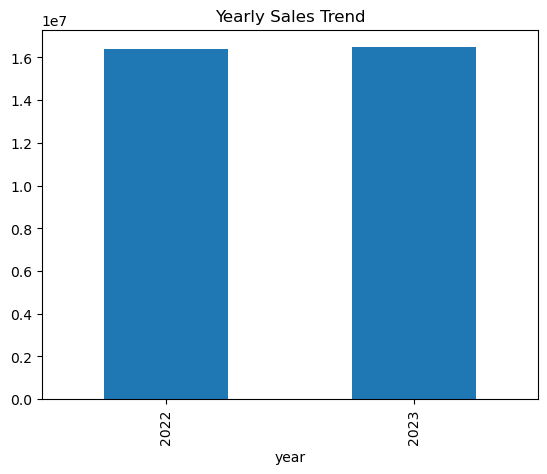

In [42]:
yearly_sales = df.groupby('year')['sales'].sum()

yearly_sales.plot(kind='bar')
plt.title("Yearly Sales Trend")
plt.show()

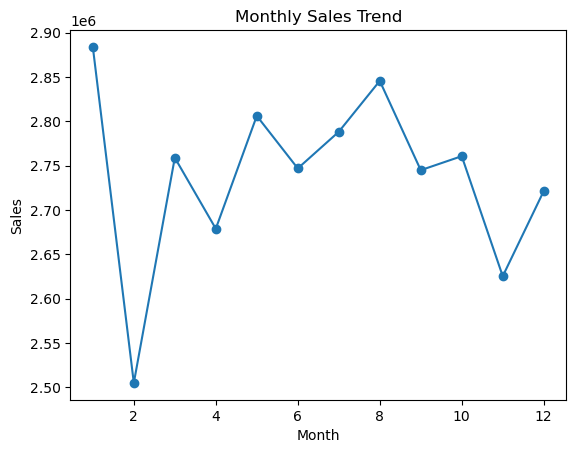

In [43]:
monthly_sales = df.groupby('month')['sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

#### 3. Category Performance: Which product categories generate the highest sales and profit?

In [45]:
category_sales = df.groupby('product_category')[['sales','profit']].sum()

print(category_sales.sort_values(by='sales', ascending=False))

                       sales     profit
product_category                       
Beauty            5550624.97 -854361.49
Books             5484863.03 -850345.81
Fashion           5480123.34 -839718.81
Home & Kitchen    5473132.55 -824399.96
Electronics       5470594.03 -832574.49
Sports            5407235.82 -845130.24


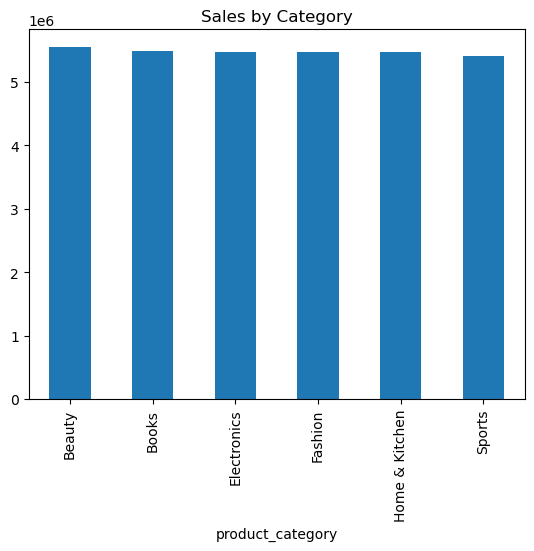

In [46]:
category_sales['sales'].plot(kind='bar')
plt.title("Sales by Category")
plt.show()

#### 4. Sub-Category Analysis: What are the top 5 sub-categories by sales or profit?

In [48]:
top_products = df.groupby('product_id')['sales'].sum().sort_values(ascending=False).head(5)

print(top_products)

product_id
1931    18885.83
1087    18531.52
1328    18306.73
3537    18071.02
2837    17855.07
Name: sales, dtype: float64


#### 5. Regional Performance: Which region performs best in terms of sales and profit?

In [49]:
region_sales = df.groupby('customer_region')[['sales','profit']].sum()

print(region_sales.sort_values(by='sales', ascending=False))

                      sales      profit
customer_region                        
Middle East      8301844.50 -1267824.46
North America    8277217.84 -1256156.65
Asia             8175199.83 -1274937.84
Europe           8112311.57 -1247611.85


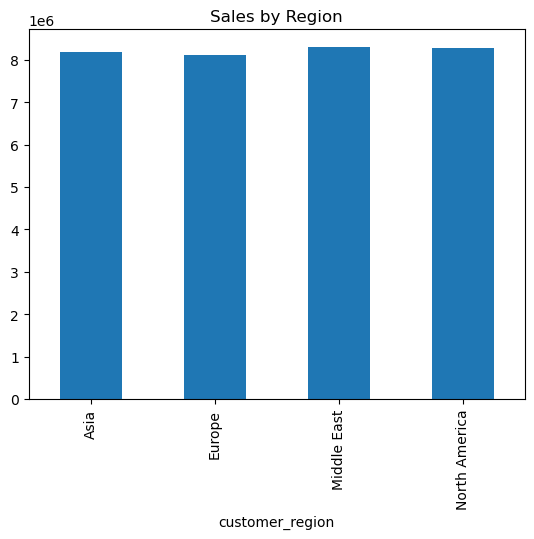

In [50]:
region_sales['sales'].plot(kind='bar')
plt.title("Sales by Region")
plt.show()

#### 6. Profitability Analysis: Are there categories or sub-categories with high sales but low profit?

In [51]:
profit_analysis = df.groupby('product_category')[['sales','profit']].sum()

profit_analysis['profit_margin'] = profit_analysis['profit'] / profit_analysis['sales']

print(profit_analysis.sort_values(by='profit_margin'))

                       sales     profit  profit_margin
product_category                                      
Sports            5407235.82 -845130.24      -0.156296
Books             5484863.03 -850345.81      -0.155035
Beauty            5550624.97 -854361.49      -0.153922
Fashion           5480123.34 -839718.81      -0.153230
Electronics       5470594.03 -832574.49      -0.152191
Home & Kitchen    5473132.55 -824399.96      -0.150627


#### 7. Customer Purchasing Behavior
 a.  What is the distribution of order quantities?

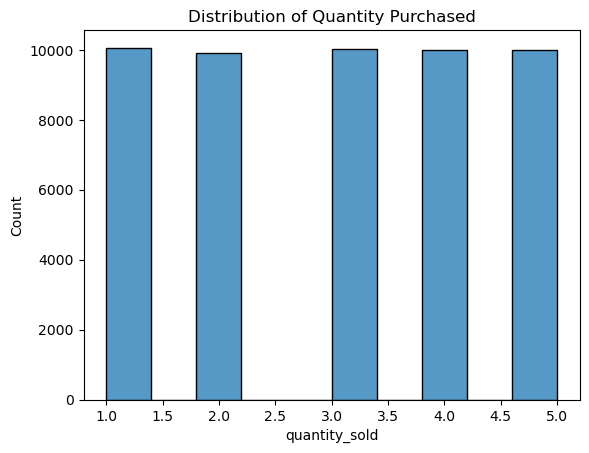

In [52]:
sns.histplot(df['quantity_sold'], bins=10)
plt.title("Distribution of Quantity Purchased")
plt.show()

b. Do customers tend to buy in small or large quantities?

In [53]:
df['quantity_sold'].describe()

count    50000.000000
mean         2.999400
std          1.415401
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: quantity_sold, dtype: float64

#### 8. Relationship Analysis
 a. What is the relationship between Sales, Quantity, and Profit?

In [54]:
corr = df[['sales','quantity_sold','profit']].corr()

print(corr)

                  sales  quantity_sold    profit
sales          1.000000       0.594404 -0.493568
quantity_sold  0.594404       1.000000 -0.390958
profit        -0.493568      -0.390958  1.000000


  b. Use correlation analysis and visualizations.

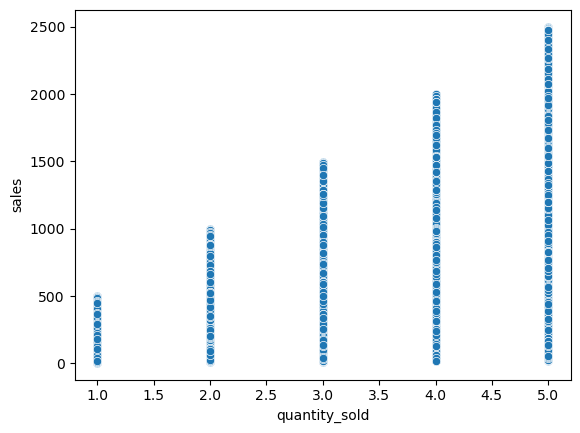

In [55]:
sns.scatterplot(x='quantity_sold', y='sales', data=df)
plt.show()

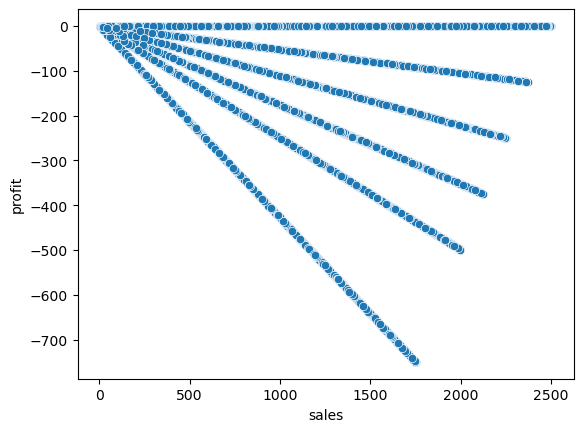

In [56]:
sns.scatterplot(x='sales', y='profit', data=df)
plt.show()